# 3 — Areas of interest

Tutorial 2 narrowed the data by *value* and by *label*. This one narrows it by
**geography**: a box, a circle, a polygon, or a vertical slice along a line.

| method | AOI | typical use |
|---|---|---|
| `crop_by_bbox` | rectangle | a map tile, a model domain |
| `crop_around_point` | circle | everything within N km of a place |
| `crop_by_polygone` | any polygon | a catchment, a canton, a shapefile |
| `extract_cross_section` | a line + beam width | a vertical slice through a storm |

The first three keep the gates and drop the rest. The fourth also computes, for
every selected gate, its position **along the line** and its **altitude** — the
geometry a vertical cross-section plot needs.

---
## The one rule: which coordinates am I in?

Every AOI runs in the **archive's own CRS**, read from `info.yaml`. You never have
to restate it. What you *do* have to say is which CRS **your own** coordinates are
in, with `crs=`:

```python
rdf.crop_around_point(point=(8.83, 46.04), distance=30_000, crs=4326)   # lon/lat
rdf.crop_around_point(point=(2680000, 1120000), distance=30_000)        # already LV95
```

Get this wrong and the crop is silently empty or in the wrong country — passing
lon/lat degrees while RadDB reads them as metres puts your AOI ~2600 km away.

In [1]:
import os
from pathlib import Path

# --------------------------------------------------------------------------
# CONFIGURATION — point these at your own data
# --------------------------------------------------------------------------
# RadDB is network-agnostic: any xarray DataTree with the standard xradar
# layout works.  These tutorials use two MeteoSwiss volumes and two NEXRAD
# volumes stored as Zarr.  Set the environment variables, or edit the paths.

MCH_DIR    = Path(os.environ.get("RADDB_DATATREE_DIR", "~/data/RADAR/MCH_datatree")).expanduser()
NEXRAD_DIR = Path(os.environ.get("RADDB_NEXRAD_DIR",   "~/data/RADAR/NEXRAD_datatree")).expanduser()

# Where the archive is written.  Anywhere you like — it is just a directory.
ARCHIVE_DIR = Path(os.environ.get("RADDB_TUTORIAL_ARCHIVE",
                                  Path(os.environ.get("TMPDIR", "/tmp")) / "raddb_tutorial_archive"))

print("MCH DataTrees   :", MCH_DIR)
print("NEXRAD DataTrees:", NEXRAD_DIR)
print("Archive         :", ARCHIVE_DIR)


MCH DataTrees   : /data/RADAR/MCH_datatree
NEXRAD DataTrees: /data/RADAR/NEXRAD_datatree
Archive         : /tmp/raddb_tutorial_archive


In [2]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import shapely
import raddb

# Keep the embedded figures small enough for GitHub to render this notebook.
plt.rcParams["figure.dpi"] = 70

In [3]:
# This notebook stands on its own: build the archive if tutorial 1 has not run.
if not (ARCHIVE_DIR / "L" / "LUT").exists():
    print("building the archive (see tutorial 1) ...")
    raddb.RadDB(archive_dir=ARCHIVE_DIR, crs=2056).archive(datatree_dir=MCH_DIR)
else:
    print("archive already present:", ARCHIVE_DIR)


archive already present: /tmp/raddb_tutorial_archive


In [4]:
db = raddb.RadDB(archive_dir=ARCHIVE_DIR)
rdf = db.open(radars="L").filter({"var": "DBZH", "logic": ">", "threshold": 5})

info = db.get_radar_info("L")
SITE = (info["longitude"], info["latitude"])          # lon, lat
print(f"radar L at {SITE[0]:.3f}, {SITE[1]:.3f}   |   {len(rdf):,} gates with echo")
print("archive CRS:", rdf.crs())

radar L at 8.833, 46.041   |   326,730 gates with echo


archive CRS: EPSG:2056


## 1. `crop_by_bbox` — a rectangle

Pass either `bounds=(minx, miny, maxx, maxy)` or `extent=(minx, maxx, miny, maxy)`
— the latter matches matplotlib's `ax.axis()` ordering.

In [5]:
box = rdf.crop_by_bbox(bounds=(8.4, 45.8, 9.3, 46.5), crs=4326)
print(f"{len(rdf):,} -> {len(box):,} gates inside the lon/lat box")
print("lon/lat extent of the result:", [round(v, 3) for v in box.geographic_extent()])

326,730 -> 286,445 gates inside the lon/lat box
lon/lat extent of the result: [8.4, 9.3, 45.8, 46.501]


## 2. `crop_around_point` — everything within N km

`distance` is in **metres**, measured in the archive's projection — so it is a true
ground distance, not a coordinate difference.

In [6]:
for km in (20, 50, 100):
    sub = rdf.crop_around_point(point=SITE, distance=km * 1_000, crs=4326)
    print(f"  within {km:>3} km : {len(sub):>8,} gates")

  within  20 km :  208,149 gates


  within  50 km :  288,718 gates


  within 100 km :  321,298 gates


In [7]:
# Any point, not only the radar itself
elsewhere = rdf.crop_around_point(point=(9.0, 46.2), distance=25_000, crs=4326)
print(f"25 km around (9.0, 46.2): {len(elsewhere):,} gates")

25 km around (9.0, 46.2): 186,802 gates


## 3. `crop_by_polygone` — an arbitrary shape

Accepts a shapely `Polygon`/`MultiPolygon`, a GeoDataFrame, or a path to a
`.shp` / `.geojson` file. A file's **declared CRS wins** unless you pass `crs=`
explicitly — a GeoJSON is lon/lat by RFC 7946, so this usually just works.

In [8]:
triangle = shapely.Polygon([(8.6, 45.9), (9.2, 46.1), (8.8, 46.5)])
poly = rdf.crop_by_polygone(polygon=triangle, crs=4326)
print(f"inside the triangle: {len(poly):,} gates")

inside the triangle: 209,103 gates


In [9]:
# The same thing from a file on disk
import json

geojson_path = ARCHIVE_DIR / "aoi_demo.geojson"
geojson_path.write_text(json.dumps({
    "type": "FeatureCollection",
    "features": [{"type": "Feature", "properties": {},
                  "geometry": shapely.geometry.mapping(triangle)}],
}))

from_file = rdf.crop_by_polygone(polygon=geojson_path)   # CRS taken from the file
print(f"from GeoJSON       : {len(from_file):,} gates  (same: {len(from_file) == len(poly)})")

from GeoJSON       : 209,103 gates  (same: True)


## 4. `extract_cross_section` — a vertical slice

A line `p1 -> p2` plus the beam width defines a vertical curtain. Every gate whose
beam intersects it is kept, and gains the geometry of the section:

| column | meaning |
|---|---|
| `d_near`, `d_far`, `d_center` | distance **along the line** from `p1` [m] |
| `z_near`, `z_far`, `z_center` | altitude above sea level [m] |
| `cs_polygon` | the gate's footprint in the (distance, altitude) plane |

Unlike an area crop, these columns are **not** LUT data — they belong to this
particular line, so they travel with the rows.

In [10]:
cs = rdf.extract_cross_section(
    p1=(SITE[0] - 0.6, SITE[1] - 0.35),
    p2=(SITE[0] + 0.6, SITE[1] + 0.35),
    crs=4326,
)
print(f"{len(cs):,} gates on the section")
print("new columns:", [c for c in cs.columns() if c.startswith(("d_", "z_", "cs_"))])

3,833 gates on the section
new columns: ['d_near', 'd_far', 'z_near', 'z_far', 'd_center', 'z_center', 'cs_polygon']


In [11]:
print(f"section length : {cs.data['d_far'].max() / 1000:.1f} km")
print(f"altitude range : {cs.data['z_near'].min():.0f} - {cs.data['z_far'].max():.0f} m ASL")
cs.data.select(["gate_id", "DBZH", "d_center", "z_center"]).head(3)

section length : 121.2 km
altitude range : 1589 - 12563 m ASL


gate_id,DBZH,d_center,z_center
i64,f32,f64,f64
21010095000749,10.0,61090.019433,1624.323017
21010105000749,12.0,61102.684205,1624.291394
21010115000749,12.0,61117.134979,1624.254759


The section is measured in true ground distance, wherever the radar is. RadDB
runs it in the archive's own CRS, so it is just as correct for a US or Finnish
radar as for a Swiss one.

In [12]:
from pyproj import Geod

p1 = (SITE[0] - 0.6, SITE[1] - 0.35)
p2 = (SITE[0] + 0.6, SITE[1] + 0.35)
truth = Geod(ellps="WGS84").inv(p1[0], p1[1], p2[0], p2[1])[2]
got = float(cs.data["d_far"].max())
print(f"true geodesic  : {truth:10,.0f} m")
print(f"section length : {got:10,.0f} m   ({100 * (got - truth) / truth:+.3f} %)")

true geodesic  :    121,167 m
section length :    121,183 m   (+0.014 %)


## 5. `quicklook=True` — did I crop what I meant to?

Every AOI method takes `quicklook=True`, which draws the AOI footprint and the
selected gates on a country-scale map. It is a sanity check, not a product.

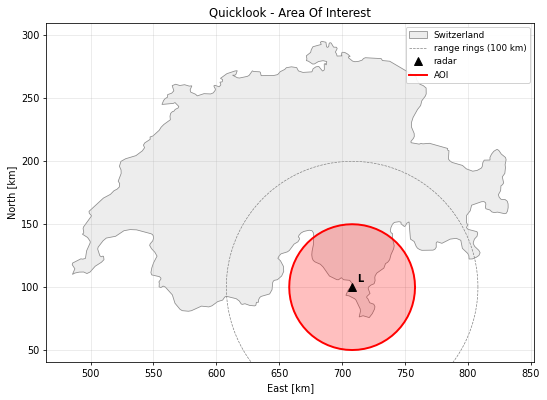

In [13]:
_ = rdf.crop_around_point(point=SITE, distance=50_000, crs=4326, quicklook=True)
plt.show()

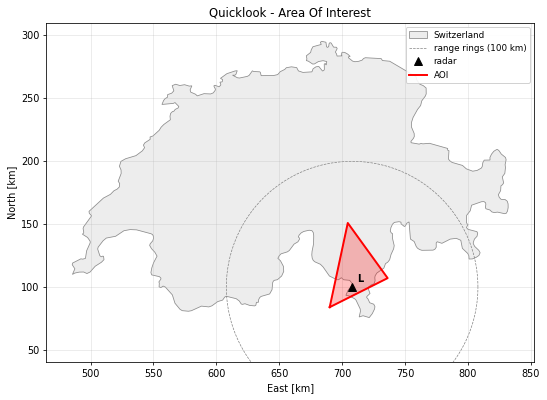

In [14]:
_ = rdf.crop_by_polygone(polygon=triangle, crs=4326, quicklook=True)
plt.show()

## 6. Chaining AOIs

Crops return a RadDB like everything else, so they compose with `filter` and `sel`
and with each other.

In [15]:
storm = (
    db.open(radars="L")
      .filter({"var": "DBZH", "logic": ">", "threshold": 25})
      .crop_around_point(point=SITE, distance=60_000, crs=4326)
      .sel(range=slice(5_000, 60_000))
)
print(f"{len(storm):,} gates: strong echo, within 60 km, beyond 5 km range")

116,865 gates: strong echo, within 60 km, beyond 5 km range


## 7. The interactive tool

In Jupyter, `interactive_crop()` puts an [ipyleaflet](https://ipyleaflet.readthedocs.io/)
map in front of you: draw a **rectangle**, **polygon**, **marker** or **polyline**,
click *Apply crop*, and the result appears on `selector.result`.

The tool dispatches on what you drew:

| you draw | RadDB runs |
|---|---|
| rectangle | `crop_by_bbox` |
| polygon | `crop_by_polygone` |
| marker | `crop_around_point` |
| **polyline** | `extract_cross_section` |

It needs a live kernel, so the cell below is switched off by default — set
`RUN_INTERACTIVE = True` and re-run it yourself.

In [16]:
RUN_INTERACTIVE = False        # <- set True in your own Jupyter session

if RUN_INTERACTIVE:
    selector = rdf.interactive_crop()
    # ... draw a shape, click "Apply crop", then:
    # cropped = selector.result
    # print(selector.kind, len(cropped))
else:
    print("interactive_crop() needs a live Jupyter kernel — set RUN_INTERACTIVE = True")
    print("\nusage:")
    print("    selector = rdf.interactive_crop()")
    print("    cropped  = selector.result   # after drawing + Apply crop")
    print("    selector.kind               # 'bbox' | 'polygon' | 'point' | 'cross_section'")

interactive_crop() needs a live Jupyter kernel — set RUN_INTERACTIVE = True

usage:
    selector = rdf.interactive_crop()
    cropped  = selector.result   # after drawing + Apply crop
    selector.kind               # 'bbox' | 'polygon' | 'point' | 'cross_section'


---
## Recap

```python
rdf.crop_by_bbox(bounds=(minx, miny, maxx, maxy), crs=4326)
rdf.crop_around_point(point=(lon, lat), distance=50_000, crs=4326)
rdf.crop_by_polygone(polygon=shape_or_path, crs=4326)
rdf.extract_cross_section(p1=(lon, lat), p2=(lon, lat), crs=4326)

rdf.crop_*(..., quicklook=True)     # sanity-check the AOI on a map
rdf.interactive_crop()              # draw it instead (Jupyter)
```

`crs=` describes **your** coordinates. The AOI itself always runs in the archive's
projection, so distances are true metres on the ground.

**Next:** [4 — Plots](04_plots.ipynb)